In [8]:
import torch
import torchvision
from torchvision.transforms import v2


print("Torch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

Torch version: 2.11.0+cu128
CUDA version: 12.8
CUDA available: True
CUDA device count: 1


In [9]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 128

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                        shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                        shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

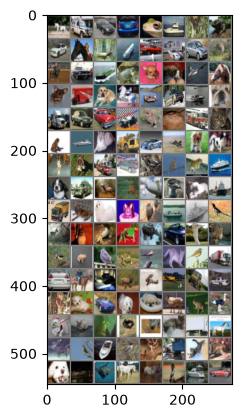

horse car   car   car   frog  ship  deer  frog  car   horse deer  ship  car   car   car   bird  horse car   ship  bird  dog   dog   bird  horse dog   truck dog   horse ship  car   ship  dog   truck car   car   car   frog  cat   truck cat   frog  ship  cat   truck car   plane dog   dog   dog   dog   truck car   frog  bird  frog  ship  dog   car   deer  deer  plane bird  dog   ship  truck dog   dog   cat   bird  ship  ship  bird  deer  cat   frog  frog  deer  car   bird  deer  bird  frog  bird  frog  bird  cat   bird  truck car   horse cat   deer  plane plane truck car   bird  dog   car   dog   dog   deer  frog  bird  dog   cat   frog  bird  cat   cat   truck horse deer  bird  ship  bird  deer  truck cat   cat   dog   ship  plane horse horse bird  ship  car  


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

class Net(nn.Module):

    
    class ResBlock(nn.Module):
        
        def __init__(self,InputDepth: int,OutputDepth: int, FilterSize: int, stride = 1) -> None:
            super().__init__()
            self.InputDepth = InputDepth
            self.OutputDepth = OutputDepth
            self.stride = stride

            self.conv1 = nn.Conv2d(InputDepth,OutputDepth,FilterSize,stride, padding= 1, bias=False)
            self.conv2 = nn.Conv2d(OutputDepth,OutputDepth,FilterSize, padding= 1, bias=False)
            
            self.bn1 = nn.BatchNorm2d(self.OutputDepth)
            self.bn2 = nn.BatchNorm2d(self.OutputDepth)

            self.ShortcutConv = None
            if stride != 1 or InputDepth != OutputDepth:
                self.ShortcutConv = nn.Sequential(
                    nn.Conv2d(InputDepth,OutputDepth,1,stride, bias=False),
                    nn.BatchNorm2d(OutputDepth)
                )

        def forward(self,x):
            i = x
            x = self.conv1(x)
            x = self.bn1(x)
            x = F.relu(x)

            x = self.conv2(x)
            x = self.bn2(x)

            if self.ShortcutConv is not None:
                i = self.ShortcutConv(i)
            x += i
            x = F.relu(x)
            return x

    def __init__(self):
        super().__init__()
        # 3 => 32 => 32 => 32 => 64 => 64 => 128 => 128 => 256 => 256 (8 layers)
        self.layers = nn.Sequential(
            self.ResBlock(3,32,3),
            self.ResBlock(32,32,3),
            self.ResBlock(32,32,3),
            self.ResBlock(32,64,3,2),
            self.ResBlock(64,64,3),
            self.ResBlock(64,128,3,2),
            self.ResBlock(128,128,3),
            self.ResBlock(128,256,3,2),
            self.ResBlock(256,256,3)
        )
        self.fc1 = nn.Linear(256 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 10)

        self.dropout = nn.Dropout(p=0.5)

    # Conv(3x3) => Conv(3x3) => Pool(2x2) => Conv(3x3) => Conv(3x3) => Pool(2x2) => Conv(3x3) => Conv(3x3) => Pool(2x2) => 
    def forward(self, x):
        # 3 x 32 x 32 (Initial)
        x = self.layers(x)
        # 256 x 4 x 4 (Block 3)
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


net = Net().to(device)

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

In [ ]:
for epoch in range(15):  # loop over the dataset multiple times
    running_loss = 0.0
    net.train()
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 50 == 49:  # print every 50 mini-batches
            print(f"Epoch {epoch+1:2d} | Batch {i+1:5d}/{len(trainloader)} | Avg loss: {running_loss/50:.4f}")
            running_loss = 0.0

print('Finished Training')

In [ ]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    net.eval()
    for data in testloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 70 %


In [ ]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    net.eval()
    for data in testloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 77.6 %
Accuracy for class: car   is 82.0 %
Accuracy for class: bird  is 62.8 %
Accuracy for class: cat   is 45.9 %
Accuracy for class: deer  is 66.5 %
Accuracy for class: dog   is 50.7 %
Accuracy for class: frog  is 83.5 %
Accuracy for class: horse is 76.8 %
Accuracy for class: ship  is 77.6 %
Accuracy for class: truck is 84.0 %
